# Search for revealing violations at strongly negative margin

This experiment tests whether final API policies contain reachable, non-revealing transmissions when the theorem margin is well below zero. It varies the EffCom transition density, receiver action count, and initialization while keeping the channel and physical-MDP seed fixed.


## Experimental design

We use $S=10$, densities $0.5$ and $0.9$, action counts $2$ and $4$, and margins $m\in\{-0.80,-0.70,-0.60\}$. With $\gamma=0.9$ and $\epsilon=0.1$, the theorem threshold is $0.81$, hence $\beta\in\{0.01,0.11,0.21\}$. Each point is trained from three deterministic policy pairs. Bellman tables use `delta_train=100`; only reachable ages through `delta_check=90` enter the main violation count.


In [1]:
from __future__ import annotations

import hashlib
import json
import multiprocessing as mp
import os
import sys
import time
import traceback
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/remote_pomdp_mpl")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "remote_api.py").exists()
)
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "negative_margin_violation_search"
RESULTS_PATH = EXPERIMENT_DIR / "results.json"
sys.path.insert(0, str(PROJECT_ROOT))

from mdp import create_effcom_control_family, initial_distribution, select_density
from remote_api import SolverConfig, initialize_policies, run_api

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.frameon": False,
})
print(f"Project root: {PROJECT_ROOT}")
print(f"Results: {RESULTS_PATH}")


Project root: /Users/rplanchon/Documents/Etudes/MVA/Stage/Imperial/work/RemotePOMDP
Results: /Users/rplanchon/Documents/Etudes/MVA/Stage/Imperial/work/RemotePOMDP/experiments/negative_margin_violation_search/results.json


In [2]:
N_STATES = 10
DENSITIES = np.array([0.5, 0.9])
ACTION_COUNTS = np.array([2, 4])
MARGINS = np.array([-0.80, -0.70, -0.60])
INIT_MODES = (
    "never_fully_observed",
    "always_random_rx",
    "state_change_random_rx",
)

GAMMA = 0.9
EPSILON = 0.1
THEOREM_THRESHOLD = GAMMA * EPSILON * (1.0 - EPSILON) / (1.0 - GAMMA)
DELTA_TRAIN = 100
DELTA_CHECK = 90
MDP_SEED = 12
MAX_WORKERS = 3

VI_TOL = 1e-10
RX_ACCEPT_TOL = 1e-9
API_TOL = 1e-9
NE_TOL = 1e-8
MARGIN_TOL = 1e-10
TIE_TOL = 1e-12

GRID = [
    (float(density), int(n_actions), float(margin), init_mode)
    for density in DENSITIES
    for n_actions in ACTION_COUNTS
    for margin in MARGINS
    for init_mode in INIT_MODES
]
assert len(GRID) == 36
assert all(THEOREM_THRESHOLD + margin > 0.0 for _, _, margin, _ in GRID)
print(f"Theorem threshold: {THEOREM_THRESHOLD:.6f}")
print("beta values:", [round(THEOREM_THRESHOLD + m, 6) for m in MARGINS])
print(f"Grid size: {len(GRID)} runs")


Theorem threshold: 0.810000
beta values: [np.float64(0.01), np.float64(0.11), np.float64(0.21)]
Grid size: 36 runs


In [3]:
for n_actions in ACTION_COUNTS:
    family = create_effcom_control_family(
        n_states=N_STATES, n_actions=int(n_actions), seed=MDP_SEED
    )
    for density in DENSITIES:
        mdp = select_density(family, float(density))
        support_sizes = np.count_nonzero(mdp.P > 0.0, axis=2)
        print(
            f"A={n_actions}, density={density:.1f}: "
            f"successors={np.unique(support_sizes).tolist()}, "
            f"reward=[{mdp.R.min():.4g}, {mdp.R.max():.4g}]"
        )


A=2, density=0.5: successors=[5], reward=[8.757e-27, 1]
A=2, density=0.9: successors=[9], reward=[8.757e-27, 1]
A=4, density=0.5: successors=[5], reward=[8.757e-27, 1]
A=4, density=0.9: successors=[9], reward=[8.757e-27, 1]


## Initial policy pairs

The baseline is the existing never-transmit / fully-observed-MDP initialization. The other two runs use distinct Tx tables and reproducible random Rx tables. Since Tx is updated first by an exact best response, the Rx differences are what primarily create different API paths; the old Tx action still controls stable tie-breaking.


In [4]:
def build_initial_policies(mdp, config, init_mode: str):
    shape = (mdp.n_states, config.delta_train + 1, mdp.n_states)
    if init_mode == "never_fully_observed":
        return initialize_policies(
            mdp, config, seed=MDP_SEED,
            tx_mode="never", rx_mode="fully_observed",
        )

    if init_mode == "always_random_rx":
        _, pi_rx = initialize_policies(
            mdp, config, seed=1012,
            tx_mode="random", rx_mode="random",
        )
        pi_tx = np.ones(shape, dtype=np.int64)
        return pi_tx, pi_rx

    if init_mode == "state_change_random_rx":
        _, pi_rx = initialize_policies(
            mdp, config, seed=2012,
            tx_mode="random", rx_mode="random",
        )
        state = np.arange(mdp.n_states)[:, None, None]
        last_received = np.arange(mdp.n_states)[None, None, :]
        pi_tx = np.broadcast_to(state != last_received, shape).astype(np.int64).copy()
        pi_tx[:, config.delta_train, :] = 1
        return pi_tx, pi_rx

    raise ValueError(f"Unknown initialization: {init_mode}")


def array_hash(array: np.ndarray) -> str:
    digest = hashlib.sha256()
    digest.update(str(array.shape).encode("ascii"))
    digest.update(np.ascontiguousarray(array).view(np.uint8))
    return digest.hexdigest()[:16]


## Run or resume the grid

Each worker regenerates the same physical MDP for its action count, constructs the requested initialization, runs API, and returns a compact record. `results.json` is updated after every completed run.


In [5]:
def run_key(density: float, n_actions: int, margin: float, init_mode: str) -> str:
    return (
        f"density={density:.12g}|actions={n_actions}|"
        f"margin={margin:.12g}|init={init_mode}"
    )


def run_grid_point(parameters: tuple[float, int, float, str]) -> dict:
    density, n_actions, target_margin, init_mode = parameters
    started = time.perf_counter()
    beta = THEOREM_THRESHOLD + target_margin
    key = run_key(*parameters)
    try:
        local_mdp = select_density(
            create_effcom_control_family(
                n_states=N_STATES,
                n_actions=n_actions,
                seed=MDP_SEED,
            ),
            density,
        )
        config = SolverConfig(
            gamma=GAMMA,
            beta=beta,
            epsilon=EPSILON,
            delta_train=DELTA_TRAIN,
            delta_check=DELTA_CHECK,
            boundary_model="tail",
            boundary_tx_mode="force_transmit",
            vi_tol=VI_TOL,
            rx_accept_tol=RX_ACCEPT_TOL,
            api_tol=API_TOL,
            ne_tol=NE_TOL,
            margin_tol=MARGIN_TOL,
            tie_tol=TIE_TOL,
        )
        pi_tx0, pi_rx0 = build_initial_policies(local_mdp, config, init_mode)
        initial_tx_fraction = float(pi_tx0[:, :DELTA_TRAIN, :].mean())
        result = run_api(
            local_mdp,
            config,
            mu0=initial_distribution(N_STATES),
            seed=MDP_SEED,
            initial_pi_tx=pi_tx0,
            initial_pi_rx=pi_rx0,
            compute_lower_bound=False,
        )

        final_step = result.history[-1] if result.history else {}
        if final_step and not final_step["tx_changed"] and not final_step["rx_changed"]:
            stop_reason = "policies_unchanged"
        elif final_step and abs(float(final_step["improvement"])) <= API_TOL:
            stop_reason = "api_tolerance"
        elif result.api_iterations >= config.max_api_iterations:
            stop_reason = "iteration_cap"
        else:
            stop_reason = "other"

        revealing = result.revealing
        reachable_core = [
            (s, age, u)
            for s, age, u in revealing.reachable_states
            if age <= DELTA_CHECK
        ]
        reachable_core_tx = sum(
            int(result.pi_tx[s, age, u]) for s, age, u in reachable_core
        )
        violation_history = [
            {
                "api_iteration": int(item["api_iteration"]),
                "core_violation_count": int(item["core_violation_count"]),
                "buffer_violation_count": int(item["buffer_violation_count"]),
                "boundary_adjacent_violation_count": int(
                    item["boundary_adjacent_violation_count"]
                ),
            }
            for item in result.violation_history
        ]
        objective_history = [
            {
                "api_iteration": 0,
                "objective": float(result.diagnostics["initial_objective"]),
                "improvement": None,
            }
        ] + [
            {
                "api_iteration": int(item["api_iteration"]),
                "objective": float(item["objective"]),
                "improvement": float(item["improvement"]),
            }
            for item in result.history
        ]
        maximum_violation_occupancy = max(
            (float(item["discounted_occupancy"]) for item in revealing.core_violations),
            default=0.0,
        )
        return {
            "key": key,
            "status": "ok",
            "n_states": N_STATES,
            "n_actions": n_actions,
            "density": density,
            "mdp_seed": MDP_SEED,
            "init_mode": init_mode,
            "gamma": GAMMA,
            "epsilon": EPSILON,
            "beta": float(beta),
            "margin": float(config.theorem_margin),
            "initial_tx_fraction": initial_tx_fraction,
            "initial_tx_hash": array_hash(pi_tx0),
            "initial_rx_hash": array_hash(pi_rx0),
            "final_tx_fraction": float(result.pi_tx[:, :DELTA_TRAIN, :].mean()),
            "final_tx_hash": array_hash(result.pi_tx),
            "final_rx_hash": array_hash(result.pi_rx),
            "reachable_core_state_count": len(reachable_core),
            "reachable_core_transmission_count": int(reachable_core_tx),
            "objective": float(result.objective),
            "lower_bound_objective": (
                None if result.lower_bound_objective is None
                else float(result.lower_bound_objective)
            ),
            "tx_regret": float(result.tx_regret),
            "rx_restricted_regret": float(result.rx_restricted_regret),
            "approximate_restricted_ne": bool(result.approximate_restricted_ne),
            "api_converged": bool(result.converged),
            "api_iterations": int(result.api_iterations),
            "api_stop_reason": stop_reason,
            "final_abs_improvement": (
                None if not final_step else abs(float(final_step["improvement"]))
            ),
            "core_violation_count": int(len(revealing.core_violations)),
            "buffer_violation_count": int(len(revealing.buffer_violations)),
            "boundary_adjacent_violation_count": int(
                len(revealing.boundary_adjacent_violations)
            ),
            "boundary_transmission_count": int(
                len(revealing.boundary_transmissions)
            ),
            "core_violations": revealing.core_violations,
            "maximum_core_violation_occupancy": maximum_violation_occupancy,
            "reachable_statistics": revealing.statistics,
            "violation_history": violation_history,
            "objective_history": objective_history,
            "elapsed_seconds": float(time.perf_counter() - started),
        }
    except Exception as exc:
        return {
            "key": key,
            "status": "error",
            "density": density,
            "n_actions": n_actions,
            "margin": target_margin,
            "init_mode": init_mode,
            "error_type": type(exc).__name__,
            "error": str(exc),
            "traceback": traceback.format_exc(),
            "elapsed_seconds": float(time.perf_counter() - started),
        }


def experiment_metadata() -> dict:
    return {
        "description": "Strongly negative theorem-margin violation search",
        "n_states": N_STATES,
        "densities": DENSITIES.tolist(),
        "action_counts": ACTION_COUNTS.tolist(),
        "margins": MARGINS.tolist(),
        "initializations": list(INIT_MODES),
        "gamma": GAMMA,
        "epsilon": EPSILON,
        "theorem_threshold": THEOREM_THRESHOLD,
        "betas": [float(THEOREM_THRESHOLD + margin) for margin in MARGINS],
        "delta_train": DELTA_TRAIN,
        "delta_check": DELTA_CHECK,
        "boundary_model": "tail",
        "boundary_tx_mode": "force_transmit",
        "mdp_seed": MDP_SEED,
        "mu0": initial_distribution(N_STATES).tolist(),
        "grid_size": len(GRID),
        "tolerances": {
            "vi_tol": VI_TOL,
            "rx_accept_tol": RX_ACCEPT_TOL,
            "api_tol": API_TOL,
            "ne_tol": NE_TOL,
            "margin_tol": MARGIN_TOL,
            "tie_tol": TIE_TOL,
        },
    }


def save_results(records: dict[str, dict]) -> None:
    payload = {
        "metadata": experiment_metadata(),
        "runs": sorted(
            records.values(),
            key=lambda item: (
                item["density"], item["n_actions"],
                item["margin"], item["init_mode"],
            ),
        ),
    }
    temporary_path = RESULTS_PATH.with_suffix(".json.tmp")
    temporary_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    temporary_path.replace(RESULTS_PATH)


In [6]:
if RESULTS_PATH.exists():
    cached_payload = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
    records = {item["key"]: item for item in cached_payload.get("runs", [])}
else:
    records = {}

pending = [
    parameters for parameters in GRID
    if records.get(run_key(*parameters), {}).get("status") != "ok"
]
print(f"Cached successful runs: {len(GRID) - len(pending)}/{len(GRID)}")

if pending:
    start_method = "fork" if "fork" in mp.get_all_start_methods() else None
    executor_kwargs = {"max_workers": MAX_WORKERS}
    if start_method is not None:
        executor_kwargs["mp_context"] = mp.get_context(start_method)
    started = time.perf_counter()
    with ProcessPoolExecutor(**executor_kwargs) as executor:
        futures = {executor.submit(run_grid_point, item): item for item in pending}
        for completed_count, future in enumerate(as_completed(futures), start=1):
            record = future.result()
            records[record["key"]] = record
            save_results(records)
            if completed_count == 1 or completed_count % 4 == 0 or completed_count == len(pending):
                elapsed = time.perf_counter() - started
                print(
                    f"Completed {completed_count}/{len(pending)} pending runs "
                    f"({elapsed / 60:.1f} min); latest status={record['status']}"
                )

payload = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
runs = payload["runs"]
successful_runs = [item for item in runs if item["status"] == "ok"]
failed_runs = [item for item in runs if item["status"] != "ok"]
print(f"Successful runs: {len(successful_runs)}/{len(GRID)}")
print(f"Failed runs: {len(failed_runs)}")


Cached successful runs: 36/36
Successful runs: 36/36
Failed runs: 0


## Numerical checks


In [7]:
df = pd.DataFrame(successful_runs).sort_values(
    ["init_mode", "density", "n_actions", "margin"]
).reset_index(drop=True)
df["max_restricted_regret"] = df[["tx_regret", "rx_restricted_regret"]].max(axis=1)
df["peak_training_core_violations"] = df["violation_history"].map(
    lambda history: max(item["core_violation_count"] for item in history)
)
df["peak_training_buffer_violations"] = df["violation_history"].map(
    lambda history: max(item["buffer_violation_count"] for item in history)
)

print(f"API converged: {int(df.api_converged.sum())}/{len(df)}")
print(f"Approximate restricted NE: {int(df.approximate_restricted_ne.sum())}/{len(df)}")
print(f"Runs with final core violations: {int((df.core_violation_count > 0).sum())}/{len(df)}")
print(f"Runs with temporary core violations: {int((df.peak_training_core_violations > 0).sum())}/{len(df)}")
print(f"Maximum restricted regret: {df.max_restricted_regret.max():.3e}")
print("Stopping reasons:")
print(df.api_stop_reason.value_counts().to_string())

display_columns = [
    "density", "n_actions", "margin", "beta", "init_mode",
    "objective", "core_violation_count", "peak_training_core_violations",
    "reachable_core_transmission_count", "api_iterations",
    "max_restricted_regret",
]
df[display_columns].head(12)


API converged: 36/36
Approximate restricted NE: 36/36
Runs with final core violations: 5/36
Runs with temporary core violations: 24/36
Maximum restricted regret: 0.000e+00
Stopping reasons:
api_stop_reason
policies_unchanged    36


,density,n_actions,margin,beta,init_mode,objective,core_violation_count,peak_training_core_violations,reachable_core_transmission_count,api_iterations,max_restricted_regret
0,0.5,2,-0.8,0.01,always_random_rx,1.535110,1292,4550,5547,4,0.0
1,0.5,2,-0.7,0.11,always_random_rx,1.211720,0,4550,1839,3,0.0
2,0.5,2,-0.6,0.21,always_random_rx,1.011081,0,4550,1240,3,0.0
3,0.5,4,-0.8,0.01,always_random_rx,1.948742,373,2338,5432,3,0.0
4,0.5,4,-0.7,0.11,always_random_rx,1.458477,0,2338,2760,4,0.0
5,0.5,4,-0.6,0.21,always_random_rx,1.263648,0,2338,1966,4,0.0
6,0.9,2,-0.8,0.01,always_random_rx,1.231311,0,4571,4116,3,0.0
7,0.9,2,-0.7,0.11,always_random_rx,0.897909,0,4571,487,2,0.0
8,0.9,2,-0.6,0.21,always_random_rx,0.921956,0,4571,173,6,0.0
9,0.9,4,-0.8,0.01,always_random_rx,1.426944,0,2344,6207,4,0.0


## Final core violations

Each cell is an exact final count. Color uses $\log(1+n)$ only to keep zero clearly distinct while preserving contrast if some counts are much larger than others.


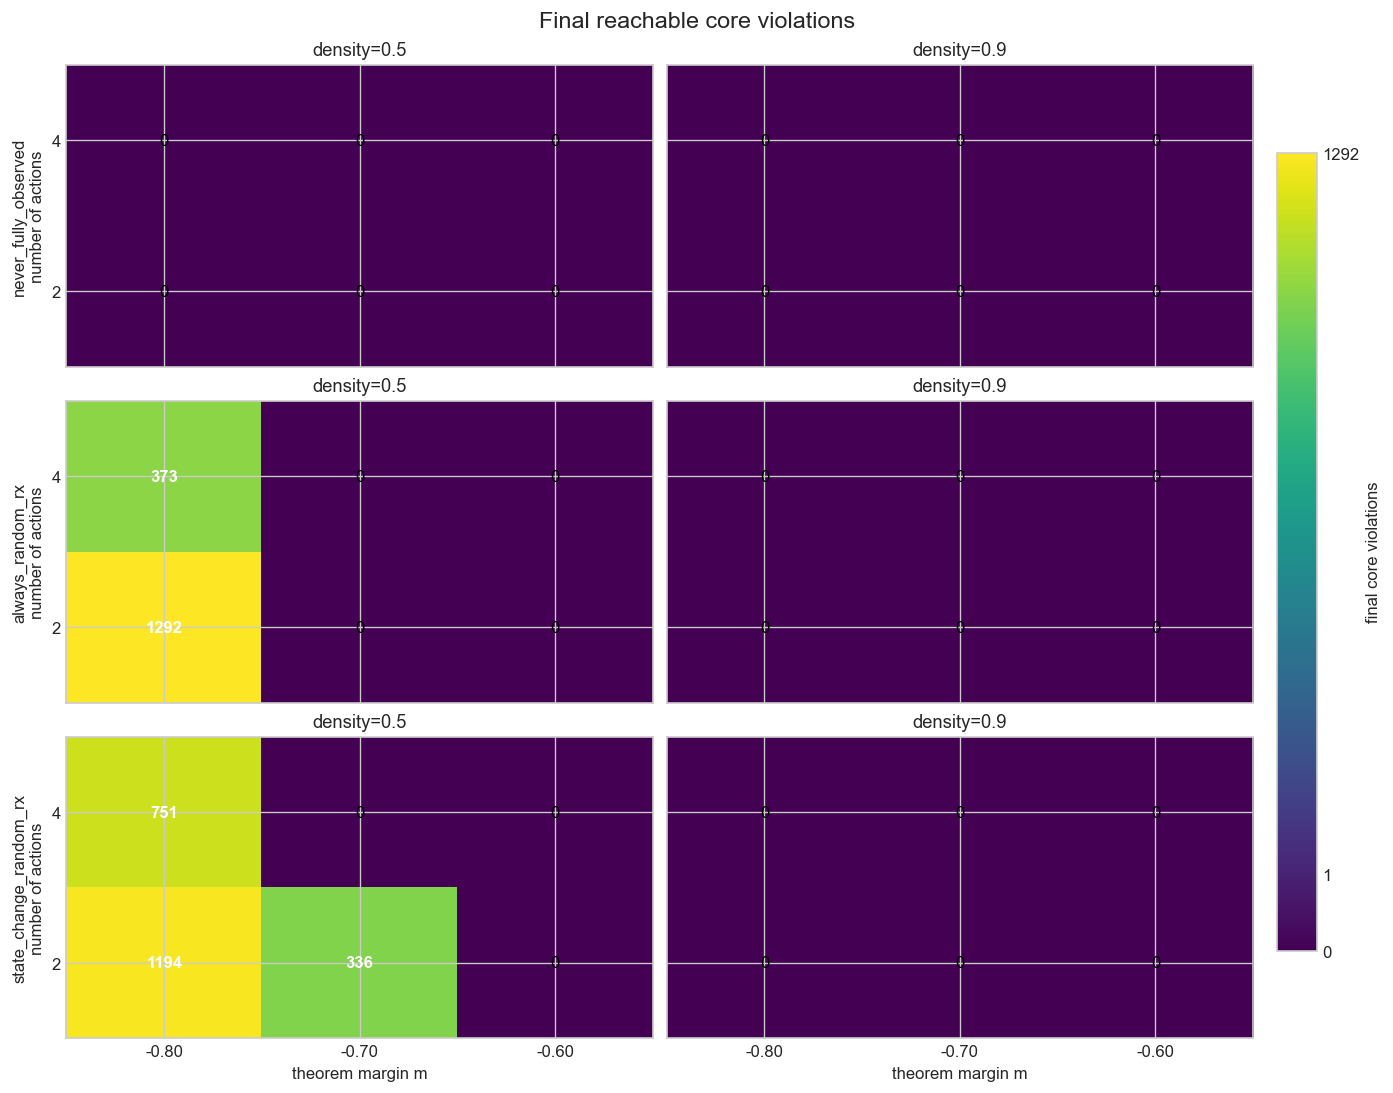

In [8]:
max_log_count = max(1.0, float(np.log1p(df.core_violation_count.max())))
fig, axes = plt.subplots(
    len(INIT_MODES), len(DENSITIES),
    figsize=(11.5, 9.0), sharex=True, sharey=True,
    constrained_layout=True,
)
last_image = None
for row, init_mode in enumerate(INIT_MODES):
    for column, density in enumerate(DENSITIES):
        ax = axes[row, column]
        subset = df[
            (df.init_mode == init_mode) & np.isclose(df.density, density)
        ]
        table = subset.pivot(
            index="n_actions", columns="margin", values="core_violation_count"
        ).reindex(index=ACTION_COUNTS, columns=MARGINS)
        counts = table.to_numpy(dtype=float)
        last_image = ax.imshow(
            np.log1p(counts), origin="lower", aspect="auto",
            cmap="viridis", vmin=0.0, vmax=max_log_count,
        )
        for action_index, n_actions in enumerate(ACTION_COUNTS):
            for margin_index, margin in enumerate(MARGINS):
                value = int(counts[action_index, margin_index])
                ax.text(
                    margin_index, action_index, str(value),
                    ha="center", va="center",
                    color="white" if np.log1p(value) > 0.55 * max_log_count else "black",
                    fontweight="bold" if value > 0 else "normal",
                )
        ax.set_xticks(np.arange(len(MARGINS)), [f"{m:.2f}" for m in MARGINS])
        ax.set_yticks(np.arange(len(ACTION_COUNTS)), ACTION_COUNTS)
        ax.set_title(f"density={density:.1f}")
        if column == 0:
            ax.set_ylabel(f"{init_mode}\nnumber of actions")
        if row == len(INIT_MODES) - 1:
            ax.set_xlabel("theorem margin m")
fig.suptitle("Final reachable core violations", fontsize=14)
if df.core_violation_count.max() > 0 and last_image is not None:
    ticks = sorted(set([0, 1, int(df.core_violation_count.max())]))
    colorbar = fig.colorbar(last_image, ax=axes, shrink=0.82, pad=0.02)
    colorbar.set_ticks([np.log1p(value) for value in ticks])
    colorbar.set_ticklabels([str(value) for value in ticks])
    colorbar.set_label("final core violations")
plt.show()


## Rotatable structural view

The three initializations are slightly offset vertically around the exact action counts to avoid marker overlap; hover text reports the exact parameters and counts.


In [9]:
from IPython.display import display as IPythonDisplay

offsets = {
    "never_fully_observed": -0.08,
    "always_random_rx": 0.0,
    "state_change_random_rx": 0.08,
}
symbols = {
    "never_fully_observed": "circle",
    "always_random_rx": "diamond",
    "state_change_random_rx": "square",
}
maximum_count = int(df.core_violation_count.max())
color_max = float(np.log1p(max(1, maximum_count)))
color_ticks = sorted(set([0, 1, maximum_count]))
traces = []
for trace_index, init_mode in enumerate(INIT_MODES):
    subset = df[df.init_mode == init_mode]
    customdata = np.column_stack([
        subset.n_actions,
        subset.core_violation_count,
        subset.peak_training_core_violations,
        subset.reachable_core_transmission_count,
        subset.beta,
        subset.objective,
    ]).tolist()
    marker = {
        "size": (6 + 2 * np.log1p(subset.core_violation_count)).tolist(),
        "symbol": symbols[init_mode],
        "color": np.log1p(subset.core_violation_count).tolist(),
        "colorscale": "Viridis",
        "cmin": 0.0,
        "cmax": color_max,
        "line": {"color": "#202020", "width": 1.0},
    }
    if trace_index == 0:
        marker["colorbar"] = {
            "title": {"text": "Core violations"},
            "tickvals": [float(np.log1p(value)) for value in color_ticks],
            "ticktext": [str(value) for value in color_ticks],
        }
    traces.append({
        "type": "scatter3d",
        "mode": "markers",
        "name": init_mode,
        "x": subset.margin.tolist(),
        "y": subset.density.tolist(),
        "z": (subset.n_actions + offsets[init_mode]).tolist(),
        "customdata": customdata,
        "marker": marker,
        "hovertemplate": (
            "m=%{x:.2f}<br>density=%{y:.1f}<br>actions=%{customdata[0]:.0f}"
            "<br>final core=%{customdata[1]:.0f}"
            "<br>training peak=%{customdata[2]:.0f}"
            "<br>reachable Tx states=%{customdata[3]:.0f}"
            "<br>beta=%{customdata[4]:.3f}<br>J=%{customdata[5]:.6g}<extra></extra>"
        ),
    })

plotly_bundle = {
    "data": traces,
    "layout": {
        "title": {"text": "Final core violations by margin and MDP structure", "x": 0.5},
        "template": "plotly_white",
        "height": 690,
        "margin": {"l": 0, "r": 20, "b": 0, "t": 55},
        "scene": {
            "xaxis": {"title": "Theorem margin m", "tickvals": MARGINS.tolist()},
            "yaxis": {"title": "Transition density", "tickvals": DENSITIES.tolist()},
            "zaxis": {"title": "Number of actions", "tickvals": ACTION_COUNTS.tolist()},
            "camera": {"eye": {"x": 1.45, "y": -1.55, "z": 1.05}},
        },
        "legend": {"x": 0.01, "y": 0.99},
    },
    "config": {"responsive": True, "displaylogo": False},
}
IPythonDisplay(
    {
        "application/vnd.plotly.v1+json": plotly_bundle,
        "text/plain": "<Rotatable Plotly 3D figure>",
    },
    raw=True,
)


<Rotatable Plotly 3D figure>

## Transmitting states after training

A zero violation count can mean either that every transmission is revealing or that the final Tx policy barely transmits. This plot separates those cases by showing the number of reachable core states where Tx transmits.


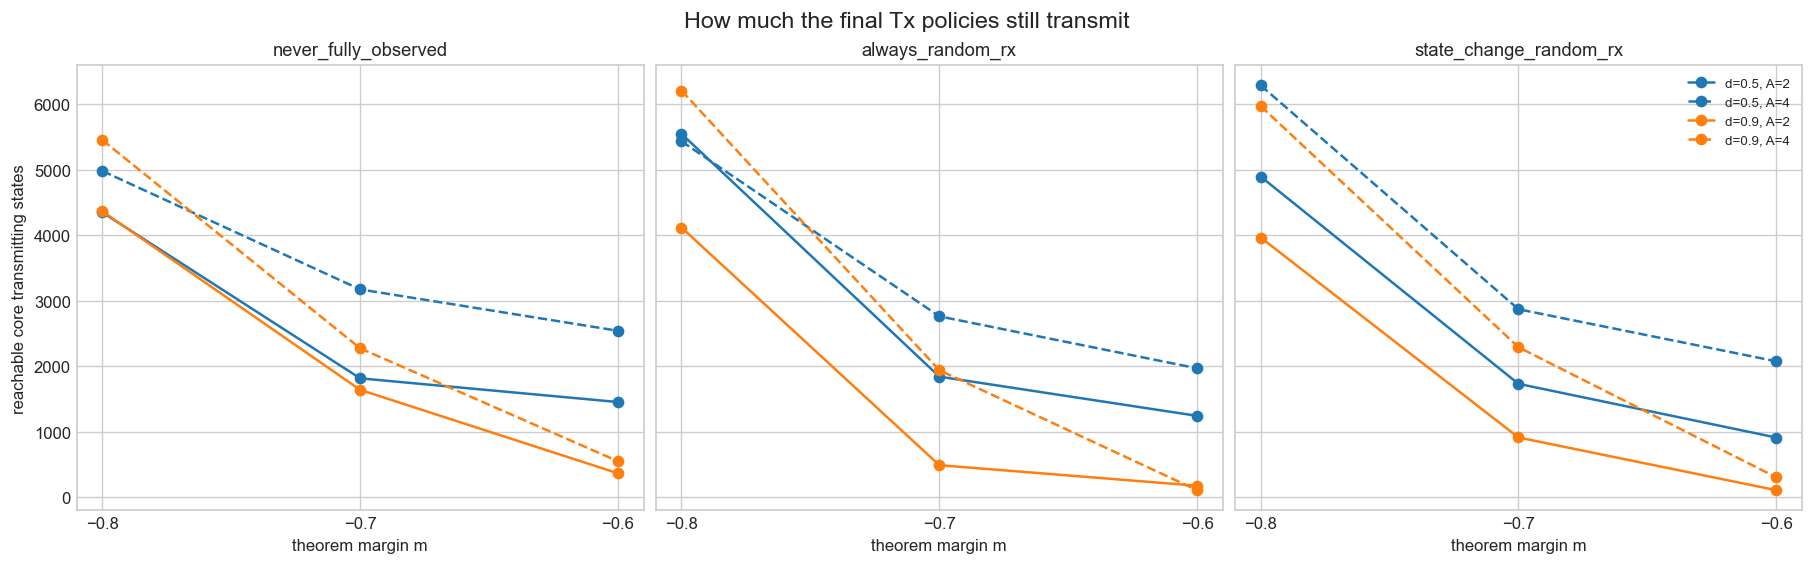

In [10]:
line_styles = {2: "-", 4: "--"}
colors = {0.5: "tab:blue", 0.9: "tab:orange"}
fig, axes = plt.subplots(1, len(INIT_MODES), figsize=(15.0, 4.6), sharey=True, constrained_layout=True)
for ax, init_mode in zip(axes, INIT_MODES):
    subset = df[df.init_mode == init_mode]
    for density in DENSITIES:
        for n_actions in ACTION_COUNTS:
            line = subset[
                np.isclose(subset.density, density) & (subset.n_actions == n_actions)
            ].sort_values("margin")
            ax.plot(
                line.margin, line.reachable_core_transmission_count,
                marker="o", linestyle=line_styles[int(n_actions)],
                color=colors[float(density)],
                label=f"d={density:.1f}, A={n_actions}",
            )
    ax.set_title(init_mode)
    ax.set_xlabel("theorem margin m")
    ax.set_xticks(MARGINS)
axes[0].set_ylabel("reachable core transmitting states")
axes[-1].legend(loc="best", fontsize=8)
fig.suptitle("How much the final Tx policies still transmit", fontsize=14)
plt.show()


## Evolution of violations during API

For each initialization, the displayed run is selected by the largest final core count and then by the largest temporary core count.


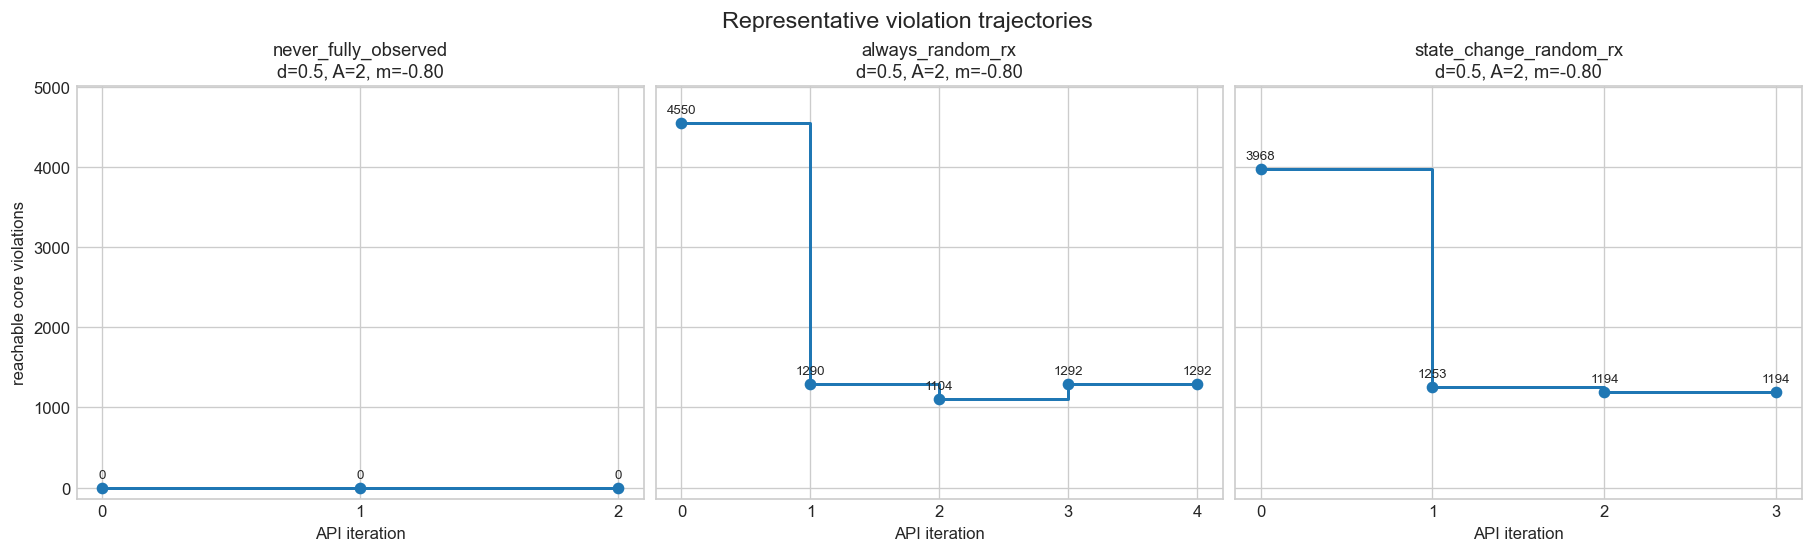

In [11]:
selected_rows = []
for init_mode in INIT_MODES:
    subset = df[df.init_mode == init_mode].sort_values(
        ["core_violation_count", "peak_training_core_violations", "margin"],
        ascending=[False, False, True],
    )
    selected_rows.append(subset.iloc[0])

global_peak = max(
    max(item["core_violation_count"] for item in row.violation_history)
    for row in selected_rows
)
fig, axes = plt.subplots(
    1, len(selected_rows), figsize=(15.0, 4.5),
    sharey=True, constrained_layout=True,
)
for ax, row in zip(axes, selected_rows):
    iterations = [item["api_iteration"] for item in row.violation_history]
    counts = [item["core_violation_count"] for item in row.violation_history]
    ax.step(iterations, counts, where="post", marker="o", linewidth=1.8)
    for iteration, count in zip(iterations, counts):
        ax.annotate(
            str(count), (iteration, count), xytext=(0, 6),
            textcoords="offset points", ha="center", fontsize=8,
        )
    ax.set_ylim(-0.03 * max(1, global_peak), 1.10 * max(1, global_peak))
    ax.set_xticks(iterations)
    ax.set_xlabel("API iteration")
    ax.set_title(
        f"{row.init_mode}\n"
        f"d={row.density:.1f}, A={row.n_actions}, m={row.margin:.2f}"
    )
axes[0].set_ylabel("reachable core violations")
fig.suptitle("Representative violation trajectories", fontsize=14)
plt.show()


## Initialization sensitivity and candidate runs


In [12]:
sensitivity = (
    df.groupby(["density", "n_actions", "margin"])
    .agg(
        distinct_final_tx=("final_tx_hash", "nunique"),
        distinct_final_rx=("final_rx_hash", "nunique"),
        min_objective=("objective", "min"),
        max_objective=("objective", "max"),
        maximum_core_violations=("core_violation_count", "max"),
    )
    .reset_index()
)
sensitivity["objective_spread"] = sensitivity.max_objective - sensitivity.min_objective
print("Groups ending at more than one final policy pair:")
display(sensitivity[
    (sensitivity.distinct_final_tx > 1) | (sensitivity.distinct_final_rx > 1)
])

candidates = df[df.core_violation_count > 0].copy()
candidate_columns = [
    "density", "n_actions", "margin", "beta", "init_mode",
    "core_violation_count", "maximum_core_violation_occupancy",
    "reachable_core_transmission_count", "objective",
    "lower_bound_objective", "tx_regret", "rx_restricted_regret",
]
if candidates.empty:
    print("No final reachable core violation was found in this grid.")
else:
    print(f"Candidate runs: {len(candidates)}")
    display(candidates[candidate_columns].sort_values(
        ["core_violation_count", "maximum_core_violation_occupancy"],
        ascending=False,
    ))
    age_counts = {}
    for _, row in candidates.iterrows():
        ages = [int(item["age"]) for item in row.core_violations]
        age_counts[row.key] = {
            str(int(age)): int(count)
            for age, count in pd.Series(ages).value_counts().sort_index().items()
        }
    print("Violation ages by candidate:")
    print(json.dumps(age_counts, indent=2))


Groups ending at more than one final policy pair:


,density,n_actions,margin,distinct_final_tx,distinct_final_rx,min_objective,max_objective,maximum_core_violations,objective_spread
0,0.5,2,-0.8,3,3,1.461696,1.535110,1292,0.073414
1,0.5,2,-0.7,3,3,0.962949,1.211720,336,0.248771
2,0.5,2,-0.6,3,3,0.950122,1.023617,0,0.073495
3,0.5,4,-0.8,3,3,1.908069,1.949961,751,0.041892
4,0.5,4,-0.7,3,3,1.458477,1.486184,0,0.027707
5,0.5,4,-0.6,3,3,1.224410,1.263648,0,0.039237
6,0.9,2,-0.8,3,3,1.231311,1.251631,0,0.020320
7,0.9,2,-0.7,3,3,0.897909,1.024785,0,0.126875
8,0.9,2,-0.6,3,3,0.921956,0.947013,0,0.025057
9,0.9,4,-0.8,3,3,1.424376,1.451355,0,0.026979


Candidate runs: 5


,density,n_actions,margin,beta,init_mode,core_violation_count,maximum_core_violation_occupancy,reachable_core_transmission_count,objective,lower_bound_objective,tx_regret,rx_restricted_regret
0,0.5,2,-0.8,0.01,always_random_rx,1292,0.213778,5547,1.535110,1.505448,0.0,0.0
24,0.5,2,-0.8,0.01,state_change_random_rx,1194,0.283431,4894,1.461696,1.434972,0.0,0.0
27,0.5,4,-0.8,0.01,state_change_random_rx,751,0.270291,6287,1.949961,1.929993,0.0,0.0
3,0.5,4,-0.8,0.01,always_random_rx,373,0.357154,5432,1.948742,1.932256,0.0,0.0
25,0.5,2,-0.7,0.11,state_change_random_rx,336,0.021423,1729,0.962949,0.934393,0.0,0.0


Violation ages by candidate:
{
  "density=0.5|actions=2|margin=-0.8|init=always_random_rx": {
    "0": 14,
    "1": 16,
    "2": 14,
    "3": 14,
    "4": 10,
    "5": 15,
    "6": 13,
    "7": 16,
    "8": 15,
    "9": 13,
    "10": 18,
    "11": 7,
    "12": 18,
    "13": 10,
    "14": 22,
    "15": 13,
    "16": 17,
    "17": 16,
    "18": 14,
    "19": 17,
    "20": 16,
    "21": 17,
    "22": 13,
    "23": 13,
    "24": 20,
    "25": 11,
    "26": 19,
    "27": 13,
    "28": 17,
    "29": 19,
    "30": 13,
    "31": 12,
    "32": 13,
    "33": 12,
    "34": 13,
    "35": 10,
    "36": 12,
    "37": 13,
    "38": 16,
    "39": 6,
    "40": 13,
    "41": 16,
    "42": 15,
    "43": 16,
    "44": 13,
    "45": 15,
    "46": 15,
    "47": 17,
    "48": 12,
    "49": 15,
    "50": 14,
    "51": 13,
    "52": 18,
    "53": 14,
    "54": 19,
    "55": 11,
    "56": 17,
    "57": 11,
    "58": 16,
    "59": 13,
    "60": 14,
    "61": 10,
    "62": 15,
    "63": 11,
    "64": 18,
    "65"

## Computed summary


In [13]:
summary = {
    "successful_runs": len(df),
    "failed_runs": len(failed_runs),
    "api_converged_runs": int(df.api_converged.sum()),
    "approximate_restricted_ne_runs": int(df.approximate_restricted_ne.sum()),
    "runs_with_final_core_violations": int((df.core_violation_count > 0).sum()),
    "runs_with_temporary_core_violations": int((df.peak_training_core_violations > 0).sum()),
    "maximum_final_core_violation_count": int(df.core_violation_count.max()),
    "maximum_training_core_violation_count": int(df.peak_training_core_violations.max()),
    "maximum_final_buffer_violation_count": int(df.buffer_violation_count.max()),
    "maximum_final_boundary_adjacent_violation_count": int(df.boundary_adjacent_violation_count.max()),
    "maximum_core_violation_occupancy": float(df.maximum_core_violation_occupancy.max()),
    "maximum_restricted_regret": float(df.max_restricted_regret.max()),
    "groups_with_multiple_final_tx_policies": int((sensitivity.distinct_final_tx > 1).sum()),
    "groups_with_multiple_final_rx_policies": int((sensitivity.distinct_final_rx > 1).sum()),
    "maximum_objective_spread_across_initializations": float(sensitivity.objective_spread.max()),
    "runs_with_lower_bound_value": int(df.lower_bound_objective.notna().sum()),
}
print(json.dumps(summary, indent=2))


{
  "successful_runs": 36,
  "failed_runs": 0,
  "api_converged_runs": 36,
  "approximate_restricted_ne_runs": 36,
  "runs_with_final_core_violations": 5,
  "runs_with_temporary_core_violations": 24,
  "maximum_final_core_violation_count": 1292,
  "maximum_training_core_violation_count": 4571,
  "maximum_final_buffer_violation_count": 133,
  "maximum_final_boundary_adjacent_violation_count": 35,
  "maximum_core_violation_occupancy": 0.35715446459043987,
  "maximum_restricted_regret": 0.0,
  "groups_with_multiple_final_tx_policies": 12,
  "groups_with_multiple_final_rx_policies": 12,
  "maximum_objective_spread_across_initializations": 0.24877081871726103,
  "runs_with_lower_bound_value": 5
}
